In [1]:
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import trange
import seaborn as sns
import numpy as np
import math
from sklearn.metrics import roc_auc_score, average_precision_score

import os
os.environ["KMP_DUPLICATE_LIB_OK"]='TRUE'

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print(device)

mps


## Load Minst Dataset

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_loader = DataLoader(datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform), batch_size=128, shuffle=True)

## Cosine Schedule

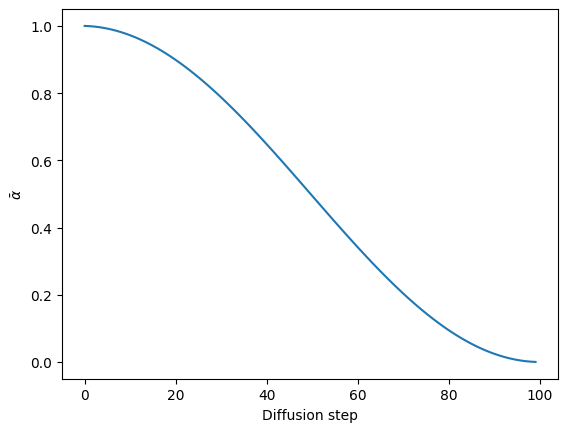

In [4]:
diffusion_steps = 100
s = 0.008
timesteps = torch.arange(0, diffusion_steps, dtype=torch.float32)
schedule = torch.cos((timesteps / diffusion_steps + s) / (1 + s) * torch.pi / 2) ** 2
baralphas = schedule / schedule[0]
betas = 1 - baralphas / torch.cat([baralphas[:1], baralphas[:-1]])
alphas = 1 - betas

sns.lineplot(baralphas)
plt.xlabel("Diffusion step")
plt.ylabel(r"$\bar{\alpha}$")
plt.show()

baralphas = baralphas.to(device)

In [5]:
def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_alphas_cumprod = baralphas[t].sqrt().view(-1, 1, 1, 1).to(device)
    sqrt_one_minus_alphas = (1 - baralphas[t]).sqrt().view(-1, 1, 1, 1).to(device)
    return sqrt_alphas_cumprod * x0 + sqrt_one_minus_alphas * noise, noise

## Demonstrate the effect of adding noise to the same image at multiple diffusion time steps.

In [6]:
def plot_diffusion_steps(x0, steps=[0, 10, 50, 99], cmap="gray"):
    x0 = x0.to(device)
    fig, axes = plt.subplots(1, len(steps), figsize=(15, 3))

    for i, t_step in enumerate(steps):
        t = torch.tensor([t_step], device=device)
        xt, _ = q_sample(x0, t)
        img = xt.squeeze().cpu().detach().numpy()

        axes[i].imshow(img, cmap=cmap)
        axes[i].set_title(f"t = {t_step}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

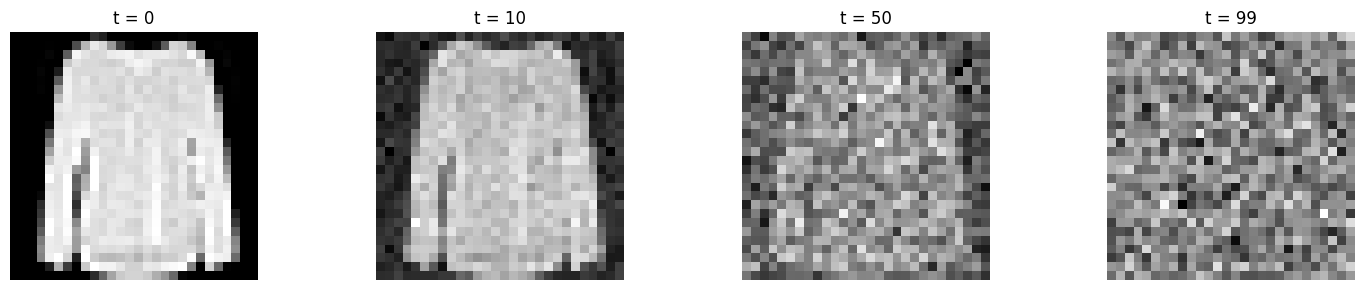

In [7]:
x_test, _ = next(iter(train_loader))
x0 = x_test[0:1]  # shape: [1, 1, 28, 28]

plot_diffusion_steps(x0, steps=[0, 10, 50, 99])


### Display the original image and the corresponding noise-added image overlaid at each time step.

In [8]:
def plot_mnist_noised_overlay(x0, steps=[0, 10, 50, 99]):
    x0 = x0.to(device)
    fig, axes = plt.subplots(1, len(steps), figsize=(3 * len(steps), 3))

    for i, t_step in enumerate(steps):
        t = torch.tensor([t_step], device=device)
        xt, _ = q_sample(x0, t)

        # 原图和加噪图 → [28, 28]
        x0_img = x0.squeeze().cpu().detach().numpy()
        xt_img = xt.squeeze().cpu().detach().numpy()

        # 创建重叠图像：原图用灰度，噪声用伪彩色红色通道（简单高亮）
        overlay = np.stack([xt_img, x0_img, x0_img], axis=-1)  # R,G,B
        overlay = np.clip(overlay, 0, 1)

        axes[i].imshow(overlay, interpolation='nearest')
        axes[i].set_title(f"t = {t_step}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()


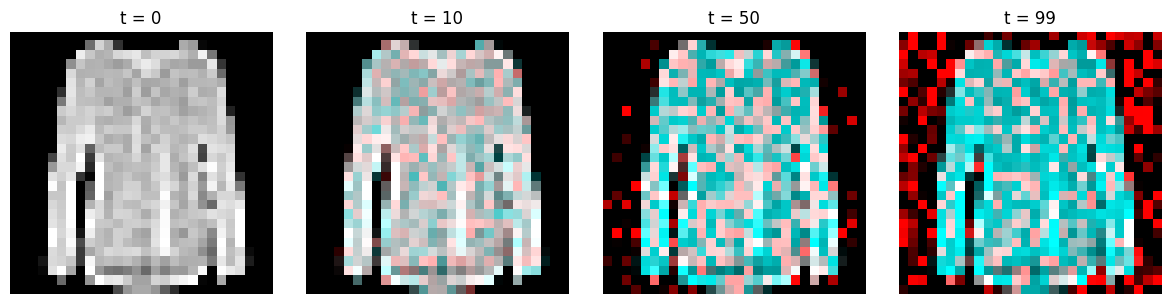

In [9]:
# x_test, _ = next(iter(train_loader))
# x0 = x_test[0:1]  # shape: [1, 1, 28, 28]

plot_mnist_noised_overlay(x0, steps=[0, 10, 50, 99])


## Define a CNN model to predict the noise at each diffusion time step.

In [10]:
# class MNISTDiffusionCNN(nn.Module):
#     def __init__(self, dropout_prob=0.1):
#         super().__init__()
#         self.conv1 = nn.Conv2d(2, 32, 3, padding=1)
#         self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
#         self.dropout = nn.Dropout2d(dropout_prob)
#         self.conv3 = nn.Conv2d(64, 1, 3, padding=1)
#
#     def forward(self, x: torch.Tensor, t: torch.Tensor):
#         t_embed = t[:, None, None, None].float() / diffusion_steps
#         t_embed = t_embed.expand(-1, 1, 28, 28).to(x.device)
#
#         xt = torch.cat([x, t_embed], dim=1)
#
#         out = F.relu(self.conv1(xt))
#         out = F.relu(self.conv2(out))
#         out = self.dropout(out)
#         out = self.conv3(out)
#         return out


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_prob=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Dropout2d(dropout_prob)
        )

    def forward(self, x):
        return self.block(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            ConvBlock(in_ch, out_ch)
        )

    def forward(self, x):
        return self.pool_conv(x)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, 2, stride=2)
        self.conv = ConvBlock(in_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # 对齐大小（必要时）
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class MNISTUNet(nn.Module):
    def __init__(self, time_dim=1):
        super().__init__()
        self.inc = ConvBlock(1 + time_dim, 32)  # 加时间通道
        self.down1 = Down(32, 64)
        self.down2 = Down(64, 128)
        self.up1 = Up(128, 64)
        self.up2 = Up(64, 32)
        self.outc = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x, t):
        # 时间嵌入广播
        t_embed = t[:, None, None, None].float() / diffusion_steps
        t_embed = t_embed.expand(-1, 1, 28, 28).to(x.device)
        xt = torch.cat([x, t_embed], dim=1)

        x1 = self.inc(xt)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x = self.up1(x3, x2)
        x = self.up2(x, x1)
        return self.outc(x)

## Monte Carlo Dropout

In [11]:
# model = MNISTDiffusionCNN().to(device)
model = MNISTUNet().to(device)

In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

In [13]:
epochs = 10
model.train()
for epoch in range(epochs):
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        t = torch.randint(0, diffusion_steps, (x.size(0),), device=device)
        noised_x, noise = q_sample(x, t)
        pred_noise = model(noised_x, t)
        loss = loss_fn(pred_noise, noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}, Loss: {total_loss / len(train_loader):.4f}")

Epoch 0, Loss: 0.2185
Epoch 1, Loss: 0.1276
Epoch 2, Loss: 0.1169
Epoch 3, Loss: 0.1126
Epoch 4, Loss: 0.1085
Epoch 5, Loss: 0.1068
Epoch 6, Loss: 0.1046
Epoch 7, Loss: 0.1052
Epoch 8, Loss: 0.1021
Epoch 9, Loss: 0.1018


### Predict the noise at t=50 for the first 16 images in the test set.

In [14]:
def predict_with_uncertainty(model, x, t, n_samples=50):
    model.train()  # 开启 Dropout
    preds = torch.stack([model(x, t) for _ in range(n_samples)])
    mean = preds.mean(0)
    std = preds.std(0)
    return mean, std

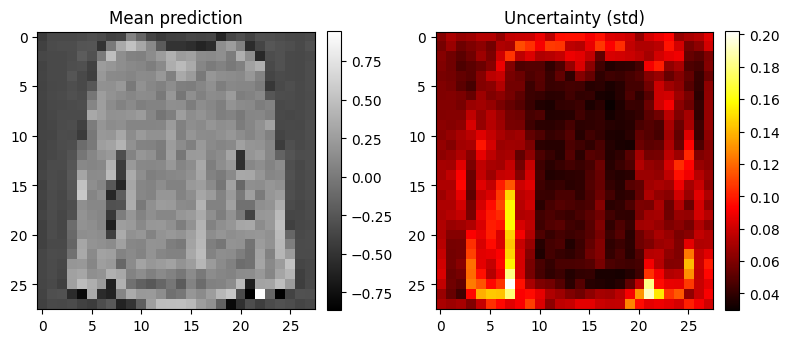

In [15]:
# x_test, _ = next(iter(train_loader))
x_test = x_test[:16].to(device)
t_test = torch.full((x_test.size(0),), 50, device=device)
mc_mean_pred, mc_std_pred = predict_with_uncertainty(model, x_test, t_test)
# print(mean_pred)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

image0 = axes[0].imshow(mc_mean_pred[0].squeeze().cpu().detach(), cmap="gray")
axes[0].set_title("Mean prediction")
plt.colorbar(image0, ax=axes[0], fraction=0.046, pad=0.04)

image1 = axes[1].imshow(mc_std_pred[0].squeeze().cpu().detach(), cmap="hot")
axes[1].set_title("Uncertainty (std)")
plt.colorbar(image1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

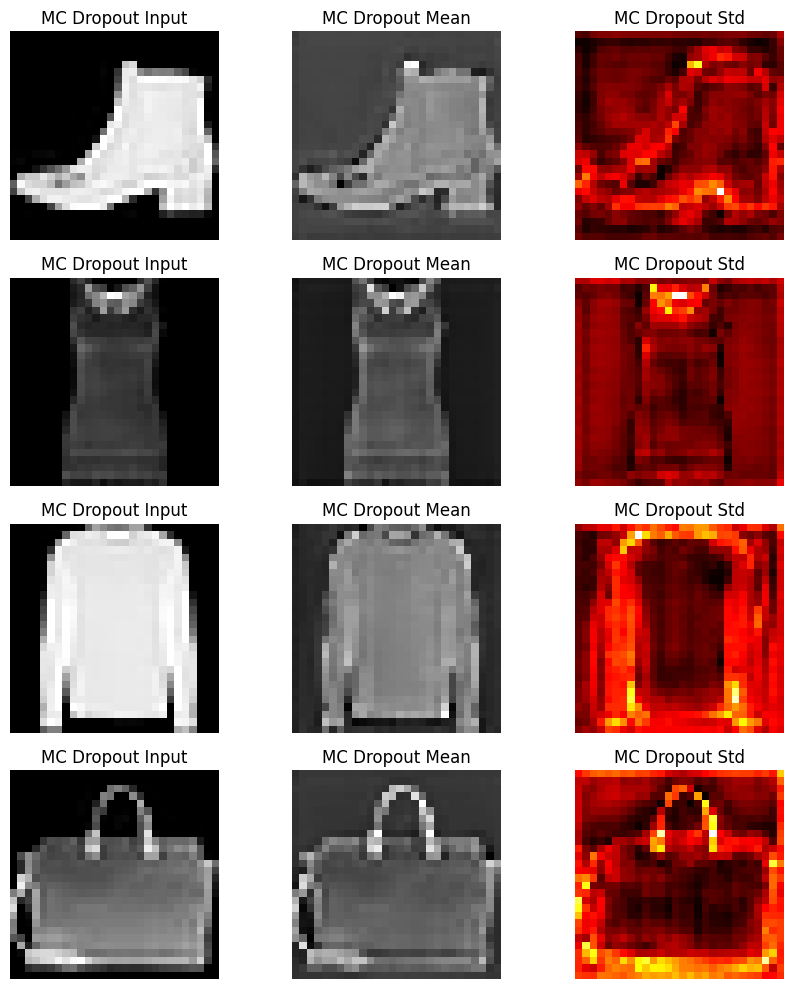

In [16]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def visualize_uncertainty_grid(mean_pred, std_pred, original=None, n=4, title_prefix="Sample"):
    B = n * n
    fig, axes = plt.subplots(n, 3, figsize=(9, n * 2.5))
    for i in range(B):
        row = i // n
        # original image
        if original is not None:
            ax0 = axes[row, 0] if n > 1 else axes[0]
            ax0.imshow(original[i].squeeze().cpu(), cmap="gray")
            ax0.set_title(f"{title_prefix} Input")
            ax0.axis("off")
        else:
            if n == 1:
                axes[0].axis("off")
            else:
                axes[row, 0].axis("off")

        # mean image
        ax1 = axes[row, 1] if n > 1 else axes[1]
        im1 = ax1.imshow(mean_pred[i].squeeze().cpu().detach(), cmap="gray")
        ax1.set_title(f"{title_prefix} Mean")
        ax1.axis("off")

        # std heatmap
        ax2 = axes[row, 2] if n > 1 else axes[2]
        im2 = ax2.imshow(std_pred[i].squeeze().cpu().detach(), cmap="hot")
        ax2.set_title(f"{title_prefix} Std")
        ax2.axis("off")

    plt.tight_layout()
    plt.show()

visualize_uncertainty_grid(
    mean_pred=mc_mean_pred,
    std_pred=mc_std_pred,
    original=x_test,
    n=4,
    title_prefix="MC Dropout"
)



In [17]:
def analyze_uncertainty(std_pred: torch.Tensor, mean_pred: torch.Tensor = None, threshold: float = 0.1):
    results = {}

    flat_std = std_pred.view(-1)

    results["uncertainty_mean"] = float(flat_std.mean())
    results["uncertainty_std"] = float(flat_std.std())
    results["uncertainty_max"] = float(flat_std.max())
    results["uncertainty_min"] = float(flat_std.min())
    results["high_uncertainty_ratio"] = float((flat_std > threshold).float().mean())

    return results

In [18]:
metrics = analyze_uncertainty(mc_std_pred, mean_pred=mc_mean_pred)

for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

uncertainty_mean: 0.0602
uncertainty_std: 0.0208
uncertainty_max: 0.2166
uncertainty_min: 0.0195
high_uncertainty_ratio: 0.0455


## Display the original image, the true noise, and the predicted noise at t=50.

In [19]:
def plot_predicted_vs_true_noise(model, x0, t_step=50):
    model.eval()
    x0 = x0.to(device)
    t = torch.tensor([t_step], device=device)

    # 加噪，获取真实噪声
    x_t, true_noise = q_sample(x0, t)

    # 模型预测噪声
    with torch.no_grad():
        pred_noise = model(x_t, t)

    mse = F.mse_loss(pred_noise, true_noise).item()
    print(f"MSE between predicted and true noise: {mse:.6f}")

    # 转为 NumPy 格式
    x0_img = x0.squeeze().cpu().numpy()
    true_noise_img = true_noise.squeeze().cpu().numpy()
    pred_noise_img = pred_noise.squeeze().cpu().numpy()

    # 绘图
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    cmap = "gray"

    axes[0].imshow(x0_img, cmap=cmap)
    axes[0].set_title("Original Image x₀")
    axes[0].axis("off")

    axes[1].imshow(true_noise_img, cmap="seismic", vmin=-1, vmax=1)
    axes[1].set_title(f"True Noise (t={t_step})")
    axes[1].axis("off")

    axes[2].imshow(pred_noise_img, cmap="seismic", vmin=-1, vmax=1)
    axes[2].set_title("Predicted Noise")
    axes[2].axis("off")

    plt.tight_layout()
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.show()

MSE between predicted and true noise: 0.040602


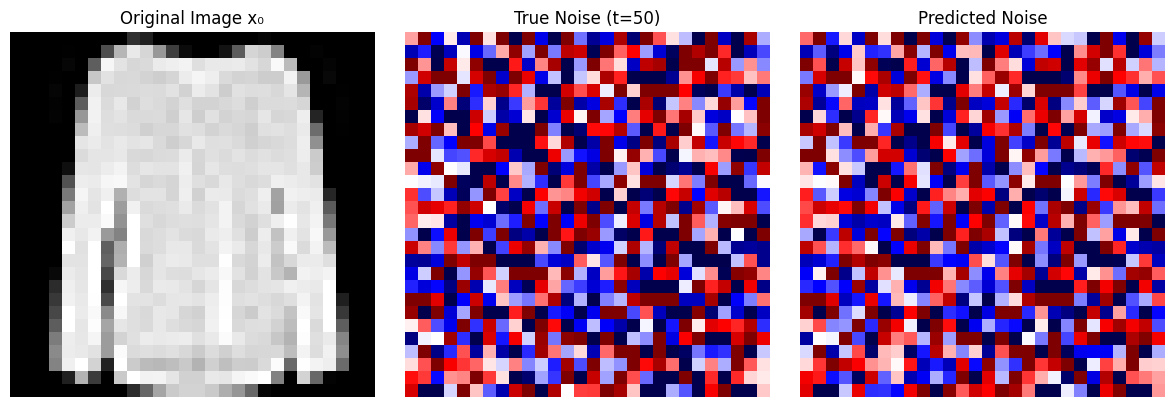

In [20]:
# x_test, _ = next(iter(train_loader))
# x0 = x_test[0:1]  # [1, 1, 28, 28]
plot_predicted_vs_true_noise(model, x0, t_step=50)

In [21]:
@torch.no_grad()
def sample_from_diffusion(model, num_samples=16, steps=diffusion_steps):
    model.eval()
    shape = (num_samples, 1, 28, 28)
    x_t = torch.randn(shape).to(device)  # 初始为纯噪声

    for t in reversed(range(1, steps)):
        t_tensor = torch.full((num_samples,), t, device=device)
        pred_noise = model(x_t, t_tensor)

        alpha = alphas[t]
        alpha_bar = baralphas[t]
        beta = betas[t]

        # DDPM论文中的反向公式：
        x_t = (1 / torch.sqrt(alpha)) * (
            x_t - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * pred_noise
        )

        # 添加噪声（除最后一步外）
        if t > 1:
            noise = torch.randn_like(x_t)
            x_t += torch.sqrt(beta) * noise

    return x_t

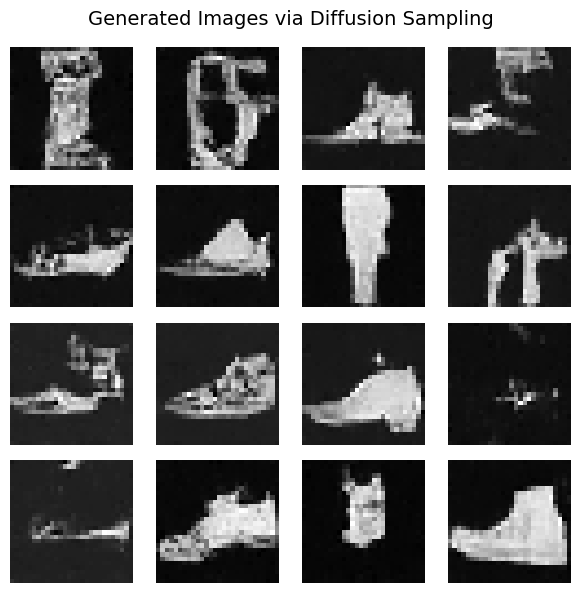

In [22]:
generated_imgs = sample_from_diffusion(model, num_samples=16)

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_imgs[i].squeeze().cpu(), cmap="gray")
    ax.axis("off")
plt.suptitle("Generated Images via Diffusion Sampling", fontsize=14)
plt.tight_layout()
plt.show()


In [23]:
def get_mc_dropout_uncertainty(model, dataloader, num_samples=20):
    model.train()  # ENABLE DROPOUT
    device = next(model.parameters()).device
    all_uncertainty = []

    with torch.no_grad():
        for batch in dataloader:
            x = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)
            b = x.shape[0]
            preds = []

            for _ in range(num_samples):
                t = torch.randint(1, diffusion_steps, (b,), device=device)
                output = model(x, t)
                preds.append(output.cpu())

            preds = torch.stack(preds)  # (S, B, 1, 28, 28)
            std_map = torch.std(preds, dim=0).squeeze(1)
            uncertainty = std_map.view(b, -1).mean(dim=1)
            all_uncertainty.append(uncertainty)

    return torch.cat(all_uncertainty).numpy()

In [24]:
id_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)
ood_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

id_loader = DataLoader(id_dataset, batch_size=128, shuffle=False)
ood_loader = DataLoader(ood_dataset, batch_size=128, shuffle=False)

In [25]:
id_uncertainty_mc = get_mc_dropout_uncertainty(model, id_loader, num_samples=20)
ood_uncertainty_mc = get_mc_dropout_uncertainty(model, ood_loader, num_samples=20)

In [26]:
labels_mc = np.concatenate([
    np.zeros(len(id_uncertainty_mc)), 
    np.ones(len(ood_uncertainty_mc))
])
scores_mc = np.concatenate([id_uncertainty_mc, ood_uncertainty_mc])

print("AUROC:", roc_auc_score(labels_mc, scores_mc))
print("AUPR:", average_precision_score(labels_mc, scores_mc))

AUROC: 0.8096485650000002
AUPR: 0.790943133619539


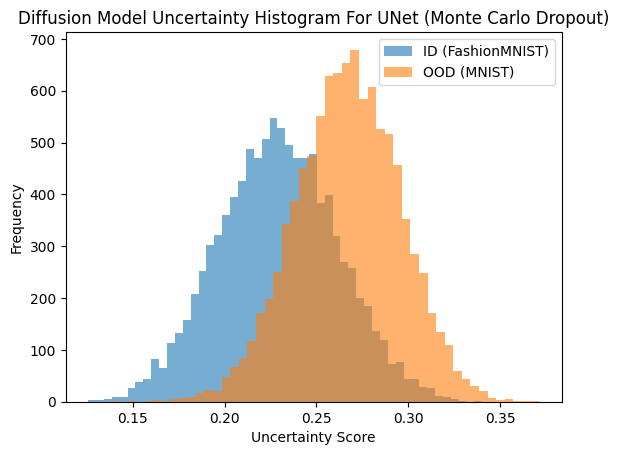

In [27]:
plt.hist(id_uncertainty_mc, bins=50, alpha=0.6, label="ID (FashionMNIST)")
plt.hist(ood_uncertainty_mc, bins=50, alpha=0.6, label="OOD (MNIST)")
plt.xlabel("Uncertainty Score")
plt.ylabel("Frequency")
plt.title("Diffusion Model Uncertainty Histogram For UNet (Monte Carlo Dropout)")
plt.legend()
plt.show()

## Deep Ensembles

### Train multiple models with different random seeds.

In [28]:
num_models = 10
ensemble_models = []

for i in range(num_models):
    torch.manual_seed(i)

    # model = MNISTDiffusionCNN().to(device)
    model = MNISTUNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # 每个模型重新初始化训练
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, _ in train_loader:
            x = x.to(device)
            t = torch.randint(0, diffusion_steps, (x.size(0),), device=device)
            noised_x, noise = q_sample(x, t)
            pred_noise = model(noised_x, t)
            loss = loss_fn(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        print(f"Model {i}, Epoch {epoch}, Loss: {total_loss / len(train_loader):.4f}")

    ensemble_models.append(model)

Model 0, Epoch 0, Loss: 0.2096
Model 0, Epoch 1, Loss: 0.1261
Model 0, Epoch 2, Loss: 0.1155
Model 0, Epoch 3, Loss: 0.1105
Model 0, Epoch 4, Loss: 0.1059
Model 0, Epoch 5, Loss: 0.1052
Model 0, Epoch 6, Loss: 0.1025
Model 0, Epoch 7, Loss: 0.1017
Model 0, Epoch 8, Loss: 0.1007
Model 0, Epoch 9, Loss: 0.1001
Model 1, Epoch 0, Loss: 0.2124
Model 1, Epoch 1, Loss: 0.1265
Model 1, Epoch 2, Loss: 0.1154
Model 1, Epoch 3, Loss: 0.1108
Model 1, Epoch 4, Loss: 0.1073
Model 1, Epoch 5, Loss: 0.1051
Model 1, Epoch 6, Loss: 0.1038
Model 1, Epoch 7, Loss: 0.1039
Model 1, Epoch 8, Loss: 0.1019
Model 1, Epoch 9, Loss: 0.1024
Model 2, Epoch 0, Loss: 0.2076
Model 2, Epoch 1, Loss: 0.1285
Model 2, Epoch 2, Loss: 0.1163
Model 2, Epoch 3, Loss: 0.1097
Model 2, Epoch 4, Loss: 0.1063
Model 2, Epoch 5, Loss: 0.1043
Model 2, Epoch 6, Loss: 0.1025
Model 2, Epoch 7, Loss: 0.1005
Model 2, Epoch 8, Loss: 0.1002
Model 2, Epoch 9, Loss: 0.0993
Model 3, Epoch 0, Loss: 0.2107
Model 3, Epoch 1, Loss: 0.1266
Model 3,

In [29]:
def predict_with_ensemble(models, x, t):
    preds = torch.stack([m(x, t) for m in models])  # shape: [n_models, B, 1, 28, 28]
    mean = preds.mean(0)
    std = preds.std(0)
    return mean, std

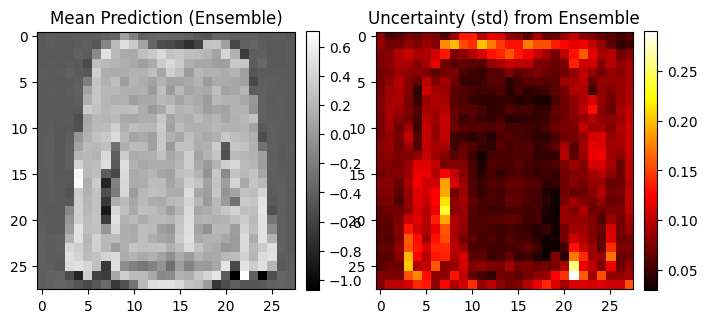

In [30]:
x_test = x_test[:16].to(device)
t_test = torch.full((x_test.size(0),), 50, device=device)
de_mean_pred, de_std_pred = predict_with_ensemble(ensemble_models, x_test, t_test)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

image0 = axes[0].imshow(de_mean_pred[0].squeeze().cpu().detach(), cmap="gray")
axes[0].set_title("Mean Prediction (Ensemble)")
plt.colorbar(image0, ax=axes[0], fraction=0.046, pad=0.04)

image1 = axes[1].imshow(de_std_pred[0].squeeze().cpu().detach(), cmap="hot")
axes[1].set_title("Uncertainty (std) from Ensemble")
plt.colorbar(image1, ax=axes[1], fraction=0.046, pad=0.04)

plt.show()

In [31]:
metrics = analyze_uncertainty(de_std_pred, mean_pred=de_mean_pred)

for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

uncertainty_mean: 0.0822
uncertainty_std: 0.0305
uncertainty_max: 0.2901
uncertainty_min: 0.0182
high_uncertainty_ratio: 0.2359


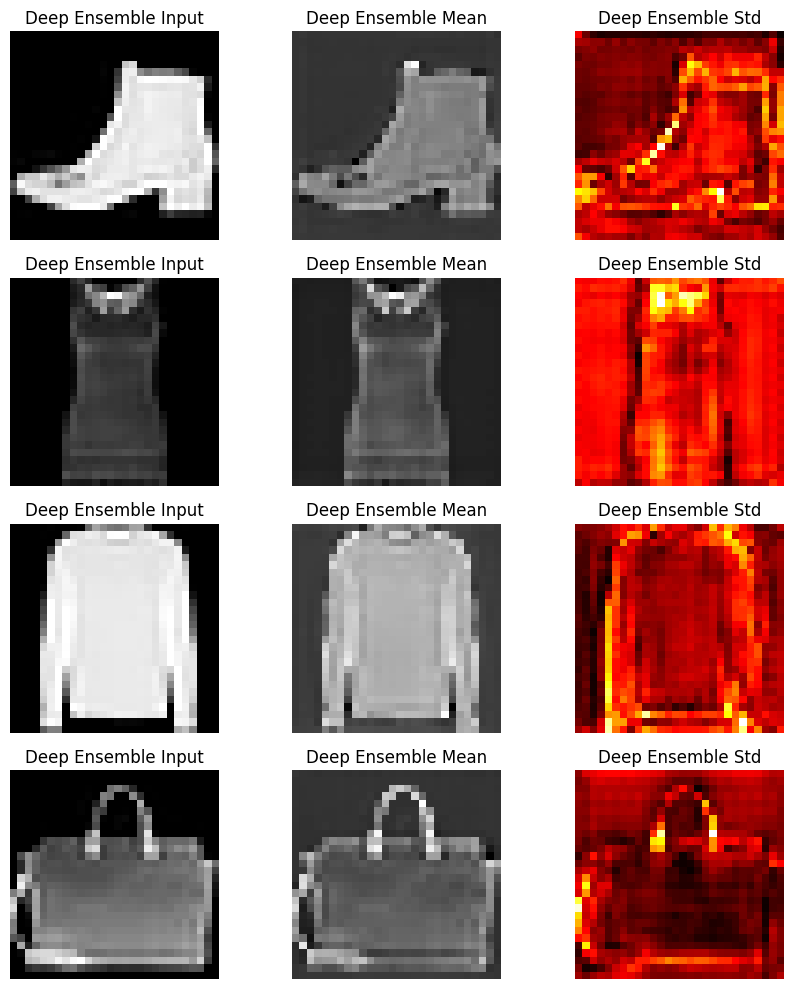

In [32]:
visualize_uncertainty_grid(
    mean_pred=de_mean_pred,
    std_pred=de_std_pred,
    original=x_test,
    n=4,
    title_prefix="Deep Ensemble"
)

In [33]:
def get_ensemble_uncertainty(ensemble_models, dataloader, num_samples=1):
    """
    Compute image-level uncertainty from an ensemble of diffusion models.
    
    Args:
        ensemble_models (List[nn.Module]): list of loaded models (already on device).
        dataloader (DataLoader): input dataloader (ID or OOD).
        num_samples (int): number of forward passes per model (for MC+Ensemble hybrid).

    Returns:
        np.ndarray: per-image uncertainty scores (mean pixel std).
    """
    device = next(ensemble_models[0].parameters()).device
    all_preds = []

    with torch.no_grad():
        for model in ensemble_models:
            model.eval()
            preds_per_model = []

            for batch in dataloader:
                x = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)
                b = x.size(0)

                model_preds = []
                for _ in range(num_samples):
                    t = torch.randint(1, diffusion_steps, (b,), device=device)
                    out = model(x, t)  # shape: (B, 1, 28, 28)
                    model_preds.append(out.cpu())

                model_preds = torch.stack(model_preds)  # (S, B, 1, 28, 28)
                mean_pred = model_preds.mean(dim=0)  # average across MC samples
                preds_per_model.append(mean_pred)

            preds_per_model = torch.cat(preds_per_model)  # (Total, 1, 28, 28)
            all_preds.append(preds_per_model)

    # Stack across models → (N_models, Total, 1, 28, 28)
    preds = torch.stack(all_preds)
    std_map = torch.std(preds, dim=0).squeeze(1)  # (Total, 28, 28)
    uncertainty = std_map.view(std_map.size(0), -1).mean(dim=1)  # (Total,)
    
    return uncertainty.numpy()

In [34]:
id_uncertainty_ensemble = get_ensemble_uncertainty(ensemble_models, id_loader)
ood_uncertainty_ensemble = get_ensemble_uncertainty(ensemble_models, ood_loader)

In [35]:
labels_ensemble = np.concatenate([
    np.zeros(len(id_uncertainty_ensemble)), 
    np.ones(len(ood_uncertainty_ensemble))
])
scores_ensemble = np.concatenate([id_uncertainty_ensemble, ood_uncertainty_ensemble])

print("AUROC:", roc_auc_score(labels_ensemble, scores_ensemble))
print("AUPR:", average_precision_score(labels_ensemble, scores_ensemble))

AUROC: 0.7440873300000002
AUPR: 0.7472949522273329


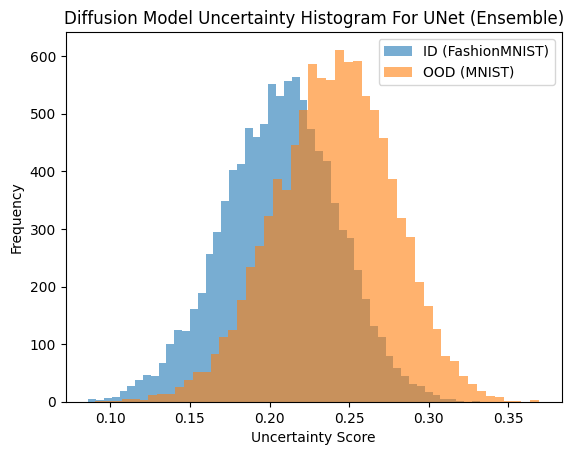

In [36]:
plt.hist(id_uncertainty_ensemble, bins=50, alpha=0.6, label="ID (FashionMNIST)")
plt.hist(ood_uncertainty_ensemble, bins=50, alpha=0.6, label="OOD (MNIST)")
plt.xlabel("Uncertainty Score")
plt.ylabel("Frequency")
plt.title("Diffusion Model Uncertainty Histogram For UNet (Ensemble)")
plt.legend()
plt.show()

## VAE

In [37]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from sklearn.metrics import roc_auc_score, average_precision_score
import seaborn as sns
import math
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import roc_curve, precision_recall_curve
import random

In [38]:
# ---------------------------------------------------------------------------- #
#                              Config & Setup                                   #
# ---------------------------------------------------------------------------- #
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print("Using device:", device)

# Hyperparameters
latent_dim = 100       # latent dimension
beta = 4.0             # beta-VAE weight
epochs = 50            # training epochs
batch_size = 128
lr = 1e-3
n_mc = 50              # MC samples for dropout
lam_kl = 0.2           # KL weight in OOD score
lam_maha = 0.1         # Mahalanobis weight

torch.manual_seed(42)
np.random.seed(42)

# ---------------------------------------------------------------------------- #
#                              Data Loaders                                    #
# ---------------------------------------------------------------------------- #
transform = transforms.Compose([
    transforms.ToTensor(),  # values in [0,1]
])
train_loader = DataLoader(
    datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)
id_test_loader = DataLoader(
    datasets.FashionMNIST(root="./data", train=False, transform=transform),
    batch_size=batch_size, shuffle=False
)
ood_test_loader = DataLoader(
    datasets.MNIST(root="./data", train=False, transform=transform),
    batch_size=batch_size, shuffle=False
)

# ---------------------------------------------------------------------------- #
#                               VAE Definition                                #
# ---------------------------------------------------------------------------- #
class ConvEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            # 28x28 -> 14x14
            nn.Conv2d(1, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            # 14x14 -> 7x7
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
        )
        self.fc_mu     = nn.Linear(128 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(128 * 7 * 7, latent_dim)

    def forward(self, x):
        h = self.net(x).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

class ConvDecoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 7 * 7)
        self.deconv = nn.Sequential(
            # 7x7 -> 14x14
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            # 14x14 -> 28x28
            nn.ConvTranspose2d(64, 1, 4, 2, 1), nn.Sigmoid()
        )

    def forward(self, z):
        h = self.fc(z).view(z.size(0), 128, 7, 7)
        return self.deconv(h)

class VAE(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.encoder = ConvEncoder(latent_dim)
        self.decoder = ConvDecoder(latent_dim)

    def reparam(self, mu, logvar):
        std = (0.5 * logvar).exp()
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparam(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

    def decode_from_mean(self, mu):
        return self.decoder(mu)

# ---------------------------------------------------------------------------- #
#                         Loss, Optimizer & Scheduler                          #
# ---------------------------------------------------------------------------- #
model = VAE(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

def loss_function(recon, x, mu, logvar):
    MSE = F.mse_loss(recon, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + beta * KLD

# ---------------------------------------------------------------------------- #
#                             Training Loop                                    #
# ---------------------------------------------------------------------------- #
for epoch in range(1, epochs+1):
    model.train()
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss = loss_function(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    avg = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch}/{epochs} — Avg loss: {avg:.4f}")

Using device: mps
Epoch 1/50 — Avg loss: 63.9404
Epoch 2/50 — Avg loss: 47.4556
Epoch 3/50 — Avg loss: 45.3786
Epoch 4/50 — Avg loss: 43.8885
Epoch 5/50 — Avg loss: 42.8366
Epoch 6/50 — Avg loss: 42.2811
Epoch 7/50 — Avg loss: 41.8014
Epoch 8/50 — Avg loss: 41.4856
Epoch 9/50 — Avg loss: 41.2790
Epoch 10/50 — Avg loss: 41.0631
Epoch 11/50 — Avg loss: 40.8203
Epoch 12/50 — Avg loss: 40.7571
Epoch 13/50 — Avg loss: 40.6521
Epoch 14/50 — Avg loss: 40.5172
Epoch 15/50 — Avg loss: 40.4084
Epoch 16/50 — Avg loss: 40.2854
Epoch 17/50 — Avg loss: 40.1963
Epoch 18/50 — Avg loss: 40.1658
Epoch 19/50 — Avg loss: 40.0948
Epoch 20/50 — Avg loss: 39.9908
Epoch 21/50 — Avg loss: 39.9447
Epoch 22/50 — Avg loss: 39.8864
Epoch 23/50 — Avg loss: 39.8305
Epoch 24/50 — Avg loss: 39.7879
Epoch 25/50 — Avg loss: 39.6480
Epoch 26/50 — Avg loss: 39.6519
Epoch 27/50 — Avg loss: 39.5520
Epoch 28/50 — Avg loss: 39.5807
Epoch 29/50 — Avg loss: 39.5160
Epoch 30/50 — Avg loss: 39.4173
Epoch 31/50 — Avg loss: 39.4256


Combined OOD AUROC: 0.9715632700000001
Combined OOD AUPR:  0.9606617914333172


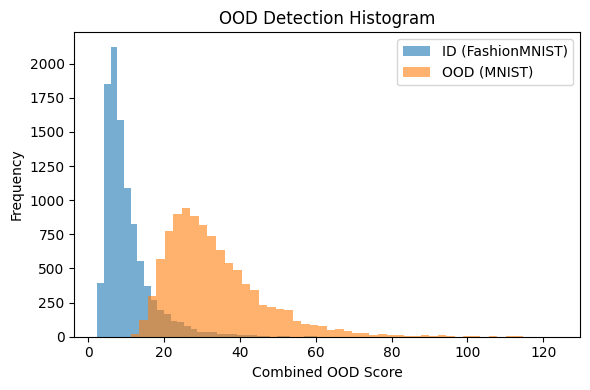

In [39]:
# ---------------------------------------------------------------------------- #
#            Compute Training Latent Means & Covariance for Mahalanobis       #
# ---------------------------------------------------------------------------- #
model.eval()
all_mu = []
with torch.no_grad():
    for x, _ in train_loader:
        mu, _ = model.encoder(x.to(device))
        all_mu.append(mu.cpu().numpy())
all_mu = np.concatenate(all_mu, axis=0)
mu_mean = all_mu.mean(axis=0)
cov = np.cov(all_mu, rowvar=False) + 1e-6 * np.eye(latent_dim)
cov_inv = np.linalg.pinv(cov)

# ---------------------------------------------------------------------------- #
#                         OOD Scoring & Metrics                                #
# ---------------------------------------------------------------------------- #
@torch.no_grad()
def compute_ood_scores(model, loader):
    model.train()
    ep_list, kl_list, maha_list = [], [], []
    for x, _ in loader:
        x = x.to(device)
        mu, logvar = model.encoder(x)
        # epistemic std 
        decs = torch.stack([model.decode_from_mean(mu) for _ in range(n_mc)], dim=0)
        std_map = decs.std(0)
        ep = std_map.view(x.size(0), -1).mean(1).cpu().numpy()
        # KL term
        kl = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)).cpu().numpy()
        # Mahalanobis
        delta = mu.cpu().numpy() - mu_mean
        maha = np.sum(delta @ cov_inv * delta, axis=1)
        ep_list.append(ep)
        kl_list.append(kl)
        maha_list.append(maha)
    return np.concatenate(ep_list), np.concatenate(kl_list), np.concatenate(maha_list)

# get scores for ID and OOD
id_ep,  id_kl,  id_maha  = compute_ood_scores(model, id_test_loader)
ood_ep, ood_kl, ood_maha = compute_ood_scores(model, ood_test_loader)

# combined score
t_id = id_ep + lam_kl * id_kl + lam_maha * id_maha
t_ood = ood_ep + lam_kl * ood_kl + lam_maha * ood_maha
labels = np.concatenate([np.zeros_like(t_id), np.ones_like(t_ood)])
scores = np.concatenate([t_id, t_ood])

print("\nCombined OOD AUROC:", roc_auc_score(labels, scores))
print("Combined OOD AUPR: ", average_precision_score(labels, scores))

# histogram
plt.figure(figsize=(6,4))
plt.hist(t_id,  bins=50, alpha=0.6, label="ID (FashionMNIST)")
plt.hist(t_ood, bins=50, alpha=0.6, label="OOD (MNIST)")
plt.xlabel("Combined OOD Score")
plt.ylabel("Frequency")
plt.title("OOD Detection Histogram")
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
def analyze_cvae_uncertainty(
    ep_unc: torch.Tensor, 
    img_score: torch.Tensor = None, 
    pixel_thresh: float = 0.1, 
    image_thresh: float = None
):
    """
    ep_unc: [B, 1, H, W] per‐pixel variance map
    img_score: [B] avg variance per image (optional)
    pixel_thresh: threshold for "high‐uncertainty" pixels
    image_thresh: threshold for "high‐uncertainty" images
    """
    results = {}

    # flatten all pixels across batch
    flat_pix = ep_unc.view(-1)
    results["pixel_mean"] = float(flat_pix.mean().item())
    results["pixel_std"]  = float(flat_pix.std().item())
    results["pixel_max"]  = float(flat_pix.max().item())
    results["pixel_min"]  = float(flat_pix.min().item())
    results["pixel_high_ratio"] = float((flat_pix > pixel_thresh).float().mean().item())

    if img_score is not None:
        # per‐image summary stats
        sc = img_score.detach().cpu()
        results["image_mean"] = float(sc.mean().item())
        results["image_std"]  = float(sc.std().item())
        results["image_max"]  = float(sc.max().item())
        results["image_min"]  = float(sc.min().item())
        if image_thresh is not None:
            results["image_high_ratio"] = float((sc > image_thresh).float().mean().item())

    return results

def estimate_epistemic_uncertainty(model, x, num_samples=100):
    model.eval()
    with torch.no_grad():
        mu, logvar = model.encoder(x.to(device))
        std = torch.exp(0.5 * logvar)

        # draw all epsilons at once → (S, B, D)
        eps = torch.randn(num_samples, *std.shape, device=std.device)
        z = mu.unsqueeze(0) + eps * std.unsqueeze(0)

        # flatten to (S*B, D), decode, then un-flatten
        z_flat = z.view(-1, z.size(-1))
        recon_flat = model.decoder(z_flat)
        recon = recon_flat.view(num_samples, *x.shape)

        # per-pixel epistemic uncertainty:
        epistemic_uncertainty = recon.var(dim=0) 
        # per-image summary score:
        uncertainty_score = epistemic_uncertainty.view(x.size(0), -1).mean(dim=1)

    return epistemic_uncertainty, uncertainty_score


epi_unc, scores = estimate_epistemic_uncertainty(model, x, num_samples=50)

metrics = analyze_cvae_uncertainty(
    ep_unc     = epi_unc, 
    img_score  = scores, 
    pixel_thresh = 0.05,      # tune to your typical pixel‐variance range
    image_thresh = 0.88       # e.g. your 95th‐percentile cut
)

for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

pixel_mean: 0.0171
pixel_std: 0.0248
pixel_max: 0.1859
pixel_min: 0.0000
pixel_high_ratio: 0.0964
image_mean: 0.0171
image_std: 0.0056
image_max: 0.0387
image_min: 0.0079
image_high_ratio: 0.0000


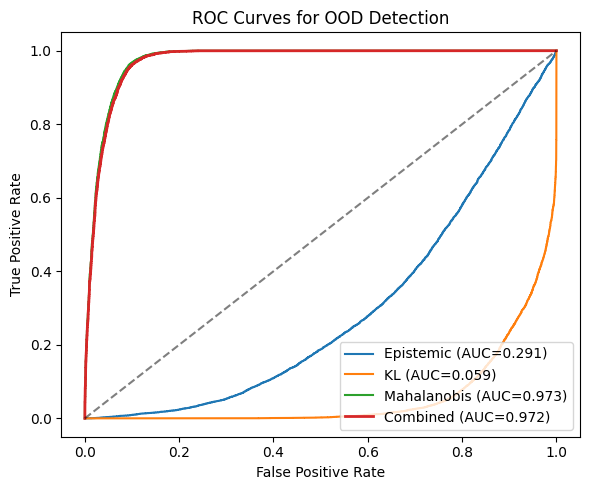

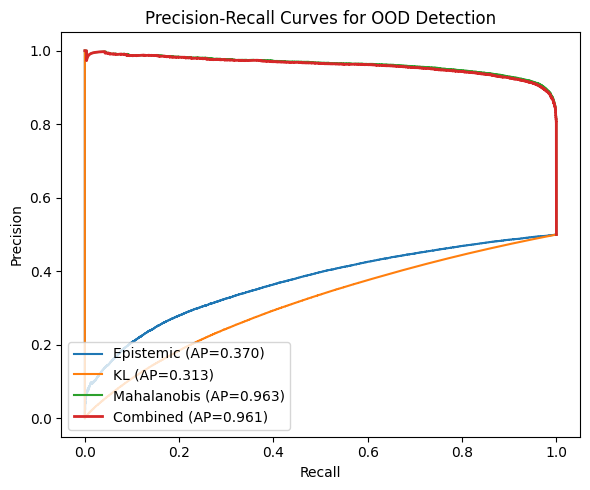

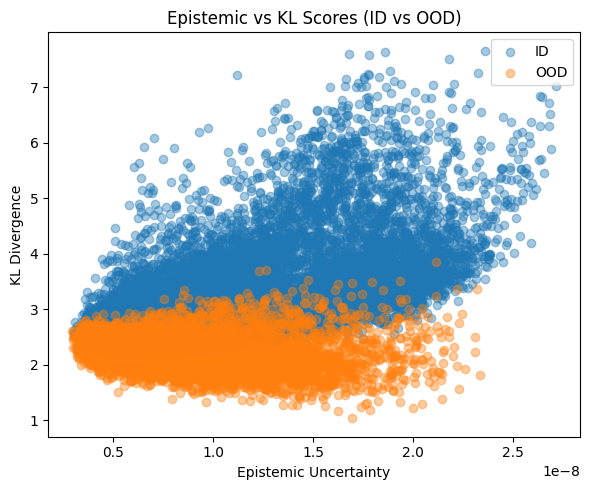

In [41]:
# Prepare labels and scores from earlier
labels = np.concatenate([np.zeros_like(id_ep), np.ones_like(ood_ep)])
ep_scores   = np.concatenate([id_ep,  ood_ep])
kl_scores   = np.concatenate([id_kl,  ood_kl])
maha_scores = np.concatenate([id_maha,ood_maha])
combined    = np.concatenate([t_id,   t_ood])

# --- 1) ROC Curves for each score ---
fpr_ep, tpr_ep, _   = roc_curve(labels, ep_scores)
fpr_kl, tpr_kl, _   = roc_curve(labels, kl_scores)
fpr_ma, tpr_ma, _   = roc_curve(labels, maha_scores)
fpr_cb, tpr_cb, _   = roc_curve(labels, combined)

plt.figure(figsize=(6,5))
plt.plot(fpr_ep,  tpr_ep,  label=f"Epistemic (AUC={roc_auc_score(labels, ep_scores):.3f})")
plt.plot(fpr_kl,  tpr_kl,  label=f"KL (AUC={roc_auc_score(labels, kl_scores):.3f})")
plt.plot(fpr_ma,  tpr_ma,  label=f"Mahalanobis (AUC={roc_auc_score(labels, maha_scores):.3f})")
plt.plot(fpr_cb,  tpr_cb,  label=f"Combined (AUC={roc_auc_score(labels, combined):.3f})", linewidth=2)
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for OOD Detection")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# --- 2) Precision-Recall Curves ---
prec_ep, rec_ep, _   = precision_recall_curve(labels, ep_scores)
prec_kl, rec_kl, _   = precision_recall_curve(labels, kl_scores)
prec_ma, rec_ma, _   = precision_recall_curve(labels, maha_scores)
prec_cb, rec_cb, _   = precision_recall_curve(labels, combined)

plt.figure(figsize=(6,5))
plt.plot(rec_ep, prec_ep,   label=f"Epistemic (AP={average_precision_score(labels, ep_scores):.3f})")
plt.plot(rec_kl, prec_kl,   label=f"KL (AP={average_precision_score(labels, kl_scores):.3f})")
plt.plot(rec_ma, prec_ma,   label=f"Mahalanobis (AP={average_precision_score(labels, maha_scores):.3f})")
plt.plot(rec_cb, prec_cb,   label=f"Combined (AP={average_precision_score(labels, combined):.3f})", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves for OOD Detection")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

# --- 3) Scatter Epistemic vs KL ---
plt.figure(figsize=(6,5))
plt.scatter(id_ep, id_kl,   c='C0', alpha=0.4, label='ID')
plt.scatter(ood_ep, ood_kl, c='C1', alpha=0.4, label='OOD')
plt.xlabel("Epistemic Uncertainty")
plt.ylabel("KL Divergence")
plt.title("Epistemic vs KL Scores (ID vs OOD)")
plt.legend()
plt.tight_layout()
plt.show()

## ROC Plot for 3 approaches

In [42]:
prec_mc, rec_mc, _   = precision_recall_curve(labels_mc, scores_mc)
prec_en, rec_en, _   = precision_recall_curve(labels_ensemble, scores_ensemble)
prec_cb, rec_cb, _   = precision_recall_curve(labels, combined)

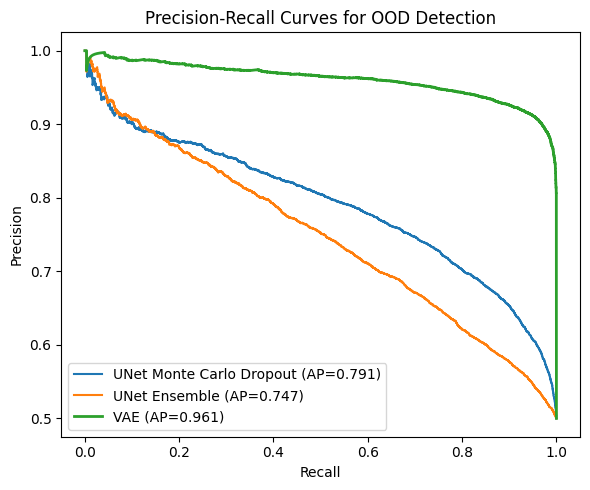

In [43]:
plt.figure(figsize=(6,5))
plt.plot(rec_mc, prec_mc,   label=f"UNet Monte Carlo Dropout (AP={average_precision_score(labels_mc, scores_mc):.3f})")
plt.plot(rec_en, prec_en,   label=f"UNet Ensemble (AP={average_precision_score(labels_ensemble, scores_ensemble):.3f})")
plt.plot(rec_cb, prec_cb,   label=f"VAE (AP={average_precision_score(labels, combined):.3f})", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves for OOD Detection")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

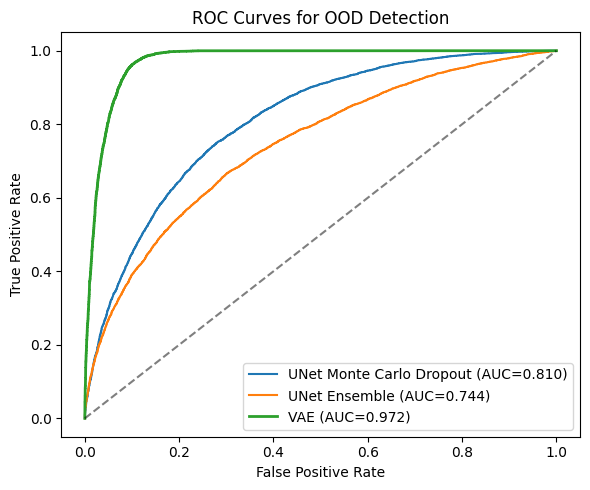

In [44]:
fpr_mc, tpr_mc, _   = roc_curve(labels_mc, scores_mc)
fpr_en, tpr_en, _   = roc_curve(labels_ensemble, scores_ensemble)
fpr_cb, tpr_cb, _   = roc_curve(labels, combined)

plt.figure(figsize=(6,5))
plt.plot(fpr_mc, tpr_mc,  label=f"UNet Monte Carlo Dropout (AUC={roc_auc_score(labels_mc, scores_mc):.3f})")
plt.plot(fpr_en, tpr_en,  label=f"UNet Ensemble (AUC={roc_auc_score(labels_ensemble, scores_ensemble):.3f})")
plt.plot(fpr_cb,  tpr_cb,  label=f"VAE (AUC={roc_auc_score(labels, combined):.3f})", linewidth=2)
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for OOD Detection")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()